# EOS table using ASE EquationOfState


In [1]:
import numpy as np
import pandas as pd
from ase.eos import EquationOfState
from scipy.optimize import minimize_scalar

from dftpy.ions import Ions
from dftpy.field import DirectField
from dftpy.grid import DirectGrid
from dftpy.functional import LocalPseudo, Functional, TotalFunctional
from dftpy.math_utils import ecut2nr
from dftpy.optimization import Optimization
from dftpy.constants import environ

from ase import units as Units

environ["LOGLEVEL"] = 4

In [2]:
# Update this path if needed
path_pp = "./OEPP_lib/OEPP/RECPOT/"


In [3]:
def get_pp_list(atom_type):
    import os
    if not os.path.isdir(path_pp):
        raise FileNotFoundError(f"Pseudopotential directory not found: {path_pp}")
    matches = [f for f in os.listdir(path_pp) if f.startswith(atom_type + "_")]
    if not matches:
        raise FileNotFoundError(
            f"No pseudopotential found for {atom_type} in {path_pp}"
        )
    file_pp = matches[0]
    return {atom_type: path_pp + file_pp}


def get_ions(atom_type, phase, a=None, dftpy=True):
    if a is None:
        raise Exception("provide lattice constant")
    from ase.build import bulk
    atoms = bulk(atom_type, phase, a=a)
    if not dftpy:
        return atoms
    ions = Ions.from_ase(atoms)
    if dftpy:
        return ions


In [4]:
def energy_at_lattice(atom_type, phase, a, kedf="WT", kedf_options=None, ecut=35):
    if kedf_options is None:
        kedf_options = {}
    ions = get_ions(atom_type, phase, a)
    nr = ecut2nr(ecut=ecut, lattice=ions.cell)
    grid = DirectGrid(lattice=ions.cell, nr=nr)
    pseudo = LocalPseudo(grid=grid, ions=ions, PP_list=get_pp_list(atom_type))
    rho_ini = DirectField(grid=grid)
    rho_ini[:] = ions.get_ncharges() / ions.cell.volume
    ke = Functional(type="KEDF", name=kedf, **kedf_options)
    xc = Functional(type="XC", name="LDA")
    hartree = Functional(type="HARTREE")
    evaluator = TotalFunctional(KE=ke, XC=xc, HARTREE=hartree, PSEUDO=pseudo)
    opt = Optimization(
        EnergyEvaluator=evaluator,
        optimization_options={"econv": 1e-6},
        optimization_method="CG",
    )
    rho = opt.optimize_rho(guess_rho=rho_ini)
    return evaluator(rho).energy * Units.Hartree


In [5]:
# Inputs
atoms = ["Al", "Si", "Sn"]
phases = ["fcc", "bcc", "diamond"]

KEDF_SPECS = [
    ("WT", {}, "WT"),
    ("WT", {"rho0": 0.3}, r"WT $\bar n = 0.3$"),
    ("WTE", {}, "WTE"),
]

# Lattice guesses (experimental)
exp_lattice = {"Si": 5.43, "Sn": 6.57, "Al": 4.05}


In [6]:
def find_min_lattice(atom_type, phase, a0, kedf, kedf_options):
    # Search +/- 10% around the starting value
    bounds = (1.0, 8.0)
    result = minimize_scalar(
        lambda a: energy_at_lattice(atom_type, phase, a, kedf, kedf_options),
        bounds=bounds,
        method="bounded",
        options={"xatol": 1e-3},
    )
    return result.x


In [ ]:
results = []
scale_factors = np.array([0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2])

for atom in atoms:
    for phase in phases:
        a0 = exp_lattice[atom]
        for kedf, kedf_options, kedf_label in KEDF_SPECS:
            a_min = find_min_lattice(atom, phase, a0, kedf, kedf_options)
            if a_min > 7.9:
                print(f"a_min for {atom} {phase} {kedf} is not good")
                continue
            print(f"a_min for {atom} {phase} {kedf} is {a_min}")
            a_values = a_min * scale_factors
            energies = []
            volumes = []
            for a in a_values:
                ions = get_ions(atom, phase, a, dftpy=False)
                volumes.append(ions.cell.volume)
                energies.append(energy_at_lattice(atom, phase, a, kedf, kedf_options))

            eos = EquationOfState(volumes, energies, eos="murnaghan")
            v0, e0, b0 = eos.fit()
            results.append({
                "Atom": atom,
                "Phase": phase,
                "KEDF": kedf_label,
                "V0": v0 / len(ions),
                "B0": b0  / Units.kJ * 1.e24,
                "a_min": a_min,
            })

results_df = pd.DataFrame(results)
results_df


a_min for Al fcc WT is not good
a_min for Al fcc WT is 4.176383509499827
a_min for Al fcc WTE is 4.190350178386271
a_min for Al bcc WT is not good
a_min for Al bcc WT is 3.3156336956916124
a_min for Al bcc WTE is 3.349645913483624
a_min for Al diamond WT is 6.27183530854353
a_min for Al diamond WT is 5.879250172310224
a_min for Al diamond WTE is 6.114843990687655
a_min for Si fcc WT is not good
a_min for Si fcc WT is 3.8591847197445164
a_min for Si fcc WTE is 4.178907485696092
a_min for Si bcc WT is not good
a_min for Si bcc WT is 3.0646584282530576
a_min for Si bcc WTE is 3.3103044629317013
a_min for Si diamond WT is not good
a_min for Si diamond WT is 5.4483448241658925
a_min for Si diamond WTE is 6.347524157501471
a_min for Sn fcc WT is 4.081806995459251
a_min for Sn fcc WT is 4.059124152924836
a_min for Sn fcc WTE is 4.081290228359866
a_min for Sn bcc WT is not good
a_min for Sn bcc WT is 3.2264088917121776
a_min for Sn bcc WTE is 3.2657744044962667
a_min for Sn diamond WT is not g

,Atom,Phase,KEDF,V0,B0,a_min
0,Al,fcc,WT $\bar n = 0.3$,18.323049,86.347044,4.176384
1,Al,fcc,WTE,18.677523,51.171222,4.190350
2,Al,bcc,WT $\bar n = 0.3$,18.337978,86.106575,3.315634
3,Al,bcc,WTE,19.083740,48.501928,3.349646
4,Al,diamond,WT,67.465478,6.727689,6.271835
5,Al,diamond,WT $\bar n = 0.3$,51.153044,46.842940,5.879250
6,Al,diamond,WTE,58.031901,24.615860,6.114844
7,Si,fcc,WT $\bar n = 0.3$,14.477367,169.002500,3.859185
8,Si,fcc,WTE,18.542547,39.924173,4.178907
9,Si,bcc,WT $\bar n = 0.3$,14.497389,168.371790,3.064658


In [8]:
eos.fit()

(62.01388104720368, -194.6951515155735, 0.1619442856536389)

<Axes: title={'center': 'murnaghan: E: -194.695 eV, V: 62.014 Å$^3$, B: 25.946 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

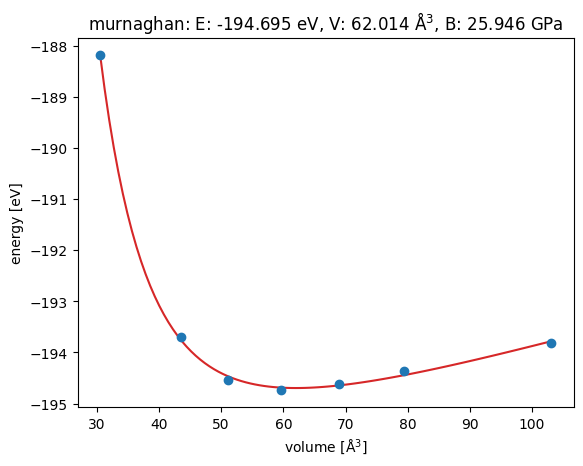

In [9]:
eos.plot()